<a href="https://colab.research.google.com/github/Jiaah116/DNSC6330-10-Individual-Week-2-Compas-analysis-python/blob/main/DNSC6330_10%E3%80%80Compas_Analysis%202%20updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**DNSC 6330-10 Weekly individual Assignment 2**

*   GWU ID: 29919940
*   Name: Yukari "Jiah" Teranishi
*   Deadline:March 31th 2026 12:00PM
*   


# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
# Load the COMPAS dataset used in the original R script.
# ensuring consistency with the lecture workflow

In [3]:
print(raw_data.shape)
raw_data.head() #Data Ceaning and prepartion

(7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [4]:
import pandas as pd

# Load the dataset from the given URL
raw_data = pd.read_csv(url)

# Filter the dataset to match the original analysis conditions
# - Keep rows where screening date is within 30 days of arrest
# - Remove rows where recidivism info is missing (is_recid = -1)
# - Remove minor traffic offenses (c_charge_degree = "O")
# - Remove rows with missing score_text
df = raw_data[
    (raw_data["days_b_screening_arrest"] >= -30) &
    (raw_data["days_b_screening_arrest"] <= 30) &
    (raw_data["is_recid"] != -1) &
    (raw_data["c_charge_degree"] != "O") &
    (raw_data["score_text"] != "N/A")
].copy()

# Create a copy of the cleaned dataset
df_main = df.copy()

# Check the column names to understand what variables are available
print(df_main.columns.tolist())

['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']


In [5]:
# Convert jail dates to datetime format
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"])
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"])

# Compute length of stay (in days)
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days

# Calculate correlation with COMPAS decile score
correlation = df["length_of_stay"].corr(df["decile_score"])

print("Correlation:", correlation)

Correlation: 0.20747808478031807


In [6]:
# Select only relevant columns (optional but cleaner)
df_model = df[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid"
]].copy()

In [7]:
# Create binary target (High vs Low/Medium)
df_model["score_factor"] = df_model["score_text"].apply(
    lambda x: "HighScore" if x != "Low" else "LowScore"
)

In [8]:
# Convert categorical variables
df_model["crime_factor"] = df_model["c_charge_degree"].astype("category")
df_model["age_factor"] = df_model["age_cat"].astype("category")
df_model["race_factor"] = df_model["race"].astype("category")
df_model["gender_factor"] = df_model["sex"].astype("category")


In [9]:
# Check result
df_model.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,score_factor,crime_factor,age_factor,race_factor,gender_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,LowScore,F,Greater than 45,Other,Male
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,LowScore,F,25 - 45,African-American,Male
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,LowScore,F,Less than 25,African-American,Male
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,LowScore,M,25 - 45,Other,Male
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,HighScore,F,25 - 45,Caucasian,Male


## Exploratory Data Analysis (EDA)

In this section, I take a closer look at the dataset to get a general sense of how the data is distributed. I focus on variables like risk scores, gender, and race to understand the overall structure before moving on to modeling. This step is helpful for spotting any imbalances or patterns that might affect later results.

In [10]:
print(df["score_text"].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [11]:
print(pd.crosstab(df["sex"], df["race"]))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [12]:
# Check gender distribution
print(df["sex"].value_counts())
print(df["sex"].value_counts(normalize=True) * 100)

sex
Male      4997
Female    1175
Name: count, dtype: int64
sex
Male      80.962411
Female    19.037589
Name: proportion, dtype: float64


In [13]:
race_counts = df["race"].value_counts()
race_percent = race_counts / len(df) * 100

# Print percentages for each race group
print("Black defendants: %.2f%%" % race_percent["African-American"])
print("White defendants: %.2f%%" % race_percent["Caucasian"])
print("Hispanic defendants: %.2f%%" % race_percent["Hispanic"])
print("Asian defendants: %.2f%%" % race_percent["Asian"])
print("Native American defendants: %.2f%%" % race_percent["Native American"])

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [14]:
# how many
recid_count = (df["two_year_recid"] == 1).sum()
print("Recidivism count:", recid_count)

# ratio
recid_rate = recid_count / len(df) * 100
print("Recidivism rate:", recid_rate)

Recidivism count: 2809
Recidivism rate: 45.51198963058976


### Key Observations

- Most defendants are classified as "Low" risk, followed by "Medium" and "High".
- The dataset is heavily skewed toward male defendants.
- African-American defendants make up the largest proportion of the dataset (~51%).
- These distributions are important when interpreting fairness and bias in the model.

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

In [15]:
import statsmodels.formula.api as smf

# Make a fresh copy from the filtered dataframe
df_glm = df.copy()

# Create categorical variables with the same reference groups as the R code
df_glm["crime_factor"] = pd.Categorical(df_glm["c_charge_degree"])
df_glm["age_factor"] = pd.Categorical(
    df_glm["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"]
)
df_glm["race_factor"] = pd.Categorical(
    df_glm["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"]
)
df_glm["gender_factor"] = pd.Categorical(
    df_glm["sex"],
    categories=["Male", "Female"]
)

# Binary target: 1 if Medium/High, 0 if Low
df_glm["score_factor"] = (df_glm["score_text"] != "Low").astype(int)

# Logistic regression equivalent to the R glm
model_glm = smf.logit(
    "score_factor ~ C(gender_factor) + C(age_factor) + C(race_factor) + priors_count + C(crime_factor) + two_year_recid",
    data=df_glm
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_factor   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        07:48:06   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.5255      0.079    

In [16]:
import numpy as np

odds_ratios = pd.DataFrame({
    "Coefficient": model_glm.params,
    "Odds Ratio": np.exp(model_glm.params)
})
print(odds_ratios)

                                    Coefficient  Odds Ratio
Intercept                             -1.525538    0.217504
C(gender_factor)[T.Female]             0.221267    1.247656
C(age_factor)[T.Greater than 45]      -1.355633    0.257784
C(age_factor)[T.Less than 25]          1.308390    3.700213
C(race_factor)[T.African-American]     0.477207    1.611567
C(race_factor)[T.Asian]               -0.254415    0.775370
C(race_factor)[T.Hispanic]            -0.428395    0.651554
C(race_factor)[T.Native American]      1.394208    4.031779
C(race_factor)[T.Other]               -0.826347    0.437645
C(crime_factor)[T.M]                  -0.311241    0.732537
priors_count                           0.268945    1.308584
two_year_recid                         0.685863    1.985484


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [17]:
# Convert selected coefficients into more interpretable ratios
control = np.exp(model_glm.params["Intercept"]) / (1 + np.exp(model_glm.params["Intercept"]))

black_effect = np.exp(model_glm.params["C(race_factor)[T.African-American]"]) / (
    1 - control + control * np.exp(model_glm.params["C(race_factor)[T.African-American]"])
)

female_effect = np.exp(model_glm.params["C(gender_factor)[T.Female]"]) / (
    1 - control + control * np.exp(model_glm.params["C(gender_factor)[T.Female]"])
)

under25_effect = np.exp(model_glm.params["C(age_factor)[T.Less than 25]"]) / (
    1 - control + control * np.exp(model_glm.params["C(age_factor)[T.Less than 25]"])
)

print("Black defendants relative effect:", black_effect)
print("Female defendants relative effect:", female_effect)
print("Under-25 defendants relative effect:", under25_effect)

Black defendants relative effect: 1.452837413382345
Female defendants relative effect: 1.194794653883451
Under-25 defendants relative effect: 2.496119530753955


Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [18]:
print("Black defendants relative effect:", black_effect)

Black defendants relative effect: 1.452837413382345


Women are 19.4% more likely than men to get a higher score.

In [19]:
print("Female defendants relative effect:", female_effect)

Female defendants relative effect: 1.194794653883451


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [20]:
print("Under-25 defendants relative effect:", under25_effect)

Under-25 defendants relative effect: 2.496119530753955


### Risk of Violent Recidivism

Compas also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score. As before, we can use a logistic regression to test for racial bias.

In [21]:
raw_data = pd.read_csv(
    "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years-violent.csv"
)
print(len(raw_data))

4743


In [22]:

df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat", "v_score_text", "sex",
    "priors_count", "days_b_screening_arrest", "v_decile_score",
    "is_recid", "two_year_recid"
]].copy()

df = df[
    (df["days_b_screening_arrest"] <= 30) &
    (df["days_b_screening_arrest"] >= -30) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["v_score_text"] != "N/A")
].copy()

print(len(df))

4020


In [23]:
print(df["age_cat"].value_counts())

age_cat
25 - 45            2300
Greater than 45     954
Less than 25        766
Name: count, dtype: int64


In [24]:
print(df["race"].value_counts())

race
African-American    1918
Caucasian           1459
Hispanic             355
Other                255
Asian                 26
Native American        7
Name: count, dtype: int64


In [25]:
print(df["v_score_text"].value_counts())

v_score_text
Low       2913
Medium     828
High       279
Name: count, dtype: int64


In [26]:
print((df["two_year_recid"] == 1).mean() * 100)

16.218905472636816


In [27]:
print((df["two_year_recid"] == 1).sum())

652


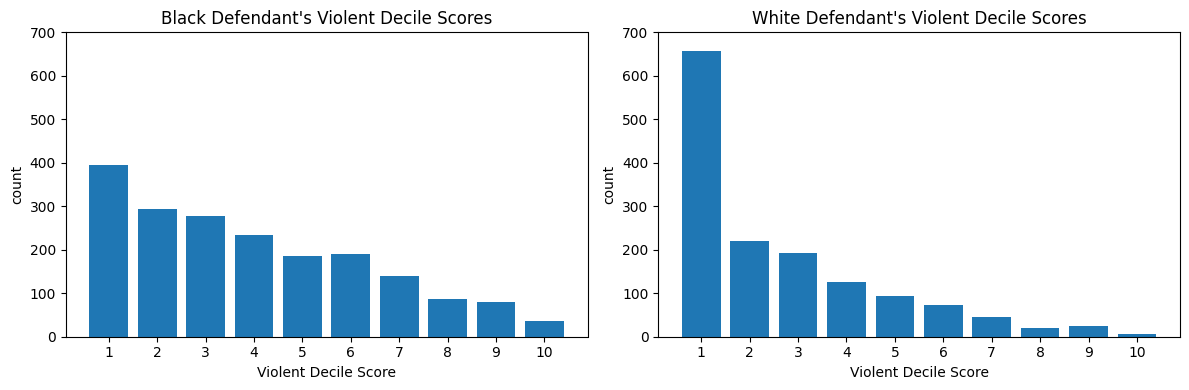

In [28]:
import matplotlib.pyplot as plt

black_counts = (
    df[df["race"] == "African-American"]["v_decile_score"]
    .value_counts()
    .sort_index()
)

white_counts = (
    df[df["race"] == "Caucasian"]["v_decile_score"]
    .value_counts()
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(black_counts.index.astype(str), black_counts.values)
axes[0].set_title("Black Defendant's Violent Decile Scores")
axes[0].set_xlabel("Violent Decile Score")
axes[0].set_ylabel("count")
axes[0].set_ylim(0, 700)

axes[1].bar(white_counts.index.astype(str), white_counts.values)
axes[1].set_title("White Defendant's Violent Decile Scores")
axes[1].set_xlabel("Violent Decile Score")
axes[1].set_ylabel("count")
axes[1].set_ylim(0, 700)

plt.tight_layout()
plt.show()

In [29]:
import statsmodels.formula.api as smf
import numpy as np

violent_glm = df.copy()

violent_glm["crime_factor"] = pd.Categorical(violent_glm["c_charge_degree"])
violent_glm["age_factor"] = pd.Categorical(
    violent_glm["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"]
)
violent_glm["race_factor"] = pd.Categorical(
    violent_glm["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"]
)
violent_glm["gender_factor"] = pd.Categorical(
    violent_glm["sex"],
    categories=["Male", "Female"]
)

violent_glm["score_factor"] = (violent_glm["v_score_text"] != "Low").astype(int)

violent_model = smf.logit(
    "score_factor ~ C(gender_factor) + C(age_factor) + C(race_factor) + priors_count + C(crime_factor) + two_year_recid",
    data=violent_glm
).fit()

print(violent_model.summary())

violent_odds = pd.DataFrame({
    "Coefficient": violent_model.params,
    "Odds Ratio": np.exp(violent_model.params)
})
print(violent_odds)

Optimization terminated successfully.
         Current function value: 0.372983
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           score_factor   No. Observations:                 4020
Model:                          Logit   Df Residuals:                     4008
Method:                           MLE   Df Model:                           11
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.3662
Time:                        07:48:08   Log-Likelihood:                -1499.4
converged:                       True   LL-Null:                       -2365.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -2.2427      0.113    

The violent score overpredicts recidivism for black defendants by 77.3% compared to white defendants.

Defendands under 25 are 7.4 times as likely to get a higher score as middle aged defendants.

In [30]:
violent_control = np.exp(violent_model.params["Intercept"]) / (
    1 + np.exp(violent_model.params["Intercept"])
)

violent_black_effect = np.exp(
    violent_model.params["C(race_factor)[T.African-American]"]
) / (
    1 - violent_control +
    violent_control * np.exp(violent_model.params["C(race_factor)[T.African-American]"])
)

violent_under25_effect = np.exp(
    violent_model.params["C(age_factor)[T.Less than 25]"]
) / (
    1 - violent_control +
    violent_control * np.exp(violent_model.params["C(age_factor)[T.Less than 25]"])
)

print(f"Black defendants relative effect: {violent_black_effect:.6f}")
print(f"Under-25 defendants relative effect: {violent_under25_effect:.6f}")

Black defendants relative effect: 1.773927
Under-25 defendants relative effect: 7.414232


## Predictive Accuracy of COMPAS

In order to test whether Compas scores do an accurate job of deciding whether an offender is Low, Medium or High risk,  we ran a Cox Proportional Hazards model. Northpointe, the company that created COMPAS and markets it to Law Enforcement, also ran a Cox model in their [validation study](http://cjb.sagepub.com/content/36/1/21.abstract).

We used the counting model and removed people when they were incarcerated. Due to errors in the underlying jail data, we need to filter out 32 rows that have an end date more than the start date. Considering that there are 13,334 total rows in the data, such a small amount of errors will not affect the results.

In [31]:
!pip install lifelines

In [32]:
grp = df_main.drop_duplicates(subset="id")
print(len(grp))

6172


The number of unique individuals differs from the original R analysis because a different dataset is used.
After filtering, the dataset contains 6172 unique individuals with no duplicates.


In [33]:
from lifelines import CoxPHFitter

cox_data = df_main.copy()
cox_data["duration"] = abs(cox_data["days_b_screening_arrest"]) + 1
cox_data["event"] = cox_data["two_year_recid"]
cox_data["score_factor"] = (cox_data["score_text"] != "Low").astype(int)

cox_data = cox_data[["duration", "event", "score_factor"]]

cph = CoxPHFitter()
cph.fit(cox_data, duration_col="duration", event_col="event")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 6172 total observations, 3363 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 6172
number of events observed = 2809
   partial log-likelihood = -22340.77
         time fit was run = 2026-03-30 07:48:25 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
score_factor  0.86      2.37      0.04            0.78            0.94                2.19                2.55

              cmp to     z      p  -log2(p)
covariate                                  
score_factor    0.00 22.13 <0.005    358.04
---
Concordance = 0.63
Partial AIC = 44683.53
log-likelihood ratio test = 508.17 on 1 df
-log2(p) of ll-ratio test = 371.39

In [34]:
import pandas as pd

cox_data = df_main.copy()
cox_data["duration"] = abs(cox_data["days_b_screening_arrest"]) + 1
cox_data["event"] = cox_data["two_year_recid"]

# 3カテゴリにする
cox_data["score_factor"] = pd.Categorical(
    cox_data["score_text"],
    categories=["Low", "Medium", "High"]
)

# ダミー変数化（Lowを基準）
cox_data = pd.get_dummies(cox_data, columns=["score_factor"], drop_first=True)

cox_data = cox_data[["duration", "event", "score_factor_Medium", "score_factor_High"]]

from lifelines import CoxPHFitter
cph = CoxPHFitter()
cph.fit(cox_data, duration_col="duration", event_col="event")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 6172 total observations, 3363 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 6172
number of events observed = 2809
   partial log-likelihood = -22305.99
         time fit was run = 2026-03-30 07:48:25 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_Medium  0.69      1.98      0.05            0.60            0.77                1.82                2.17
score_factor_High    1.09      2.97      0.05            1.00            1.18                2.71                3.25

                     cmp to     z      p  -log2(p)
covariate                                         
score_factor_Medium    0.00 15.09 <0.005    168.41
score_factor_High      0.00 23.60 <0.005    406.69
---
Concordance = 0.64
Partial AIC = 44615.98
log-likelihood ratio test = 577.72 on 2 df
-log2(p) of ll-ratio test = 416.73

In [35]:
grp = df_main.drop_duplicates(subset="id")
print(grp["race"].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [36]:
import pandas as pd

cox_url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-parsed.csv"
data = pd.read_csv(cox_url)

# Remove missing score_text rows and keep only valid counting-process rows
data = data[data["score_text"].notna() & (data["end"] > data["start"])].copy()

data["race_factor"] = pd.Categorical(
    data["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"]
)

data["score_factor"] = pd.Categorical(
    data["score_text"],
    categories=["Low", "High", "Medium"]
)

grp = data.drop_duplicates(subset="id").copy()

print(len(grp))
print(grp["score_factor"].value_counts(dropna=False))
print(grp["race_factor"].value_counts(dropna=False))

10314
score_factor
Low       5751
Medium    2611
High      1952
Name: count, dtype: int64
race_factor
African-American    5147
Caucasian           3569
Hispanic             944
Other                571
Asian                 51
Native American       32
Name: count, dtype: int64


People placed in the High category are 3.5 times as likely to recidivate, and the COMPAS system's concordance 63.6%. This is lower than the accuracy quoted in the Northpoint study of 68%.

In [37]:
from lifelines import CoxTimeVaryingFitter

cox_data = data[["id", "start", "end", "event", "score_factor"]].copy()
cox_data = pd.get_dummies(cox_data, columns=["score_factor"], drop_first=True)

ctv = CoxTimeVaryingFitter()
ctv.fit(
    cox_data,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event"
)

ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 13344 periods, 10314 subjects, 3469 events>
         event col = 'event'
number of subjects = 10314
 number of periods = 13344
  number of events = 3469
partial log-likelihood = -30305.85
  time fit was run = 2026-03-30 07:48:27 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_High    1.25      3.49      0.04            1.17            1.33                3.22                3.78
score_factor_Medium  0.80      2.22      0.04            0.72            0.88                2.05                2.40

                     cmp to     z      p  -log2(p)
covariate                                         
score_factor_High      0.00 30.14 <0.005    660.70
score_factor_Medium    0.00 19.53 <0.005    279.75
---
Partial AIC = 60615.71
log-likelihood ratio test = 942.82 on 2 df
-log2(p) of ll-ratio test = 680.10

In [38]:
from lifelines import CoxTimeVaryingFitter

# Cox model using decile score
decile_data = data[["id", "start", "end", "event", "decile_score"]].copy()

ctv_decile = CoxTimeVaryingFitter()
ctv_decile.fit(
    decile_data,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event"
)

ctv_decile.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 13344 periods, 10314 subjects, 3469 events>
         event col = 'event'
number of subjects = 10314
 number of periods = 13344
  number of events = 3469
partial log-likelihood = -30221.49
  time fit was run = 2026-03-30 07:48:42 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
decile_score  0.19      1.22      0.01            0.18            0.21                1.20                1.23

              cmp to     z      p  -log2(p)
covariate                                  
decile_score    0.00 33.61 <0.005    820.06
---
Partial AIC = 60444.98
log-likelihood ratio test = 1111.55 on 1 df
-log2(p) of ll-ratio test = 807.20

The Cox model using the COMPAS decile score shows that each one-point increase in decile score is associated with an increase in recidivism risk. The hazard ratio is approximately 1.22, meaning that for every additional point in the decile score, the risk of recidivism increases by about 22%.

This result is consistent with the original R analysis and suggests that the decile score is a meaningful predictor of recidivism.

COMPAS's decile scores are a bit more accurate at 66%.

We can test if the algorithm is behaving differently across races by including a race interaction term in the cox model.

In [39]:
from lifelines import CoxTimeVaryingFitter
import pandas as pd

# Keep only the columns needed for the interaction model
interaction_data = data[["id", "start", "end", "event", "race_factor", "score_factor"]].copy()

# Create dummy variables
interaction_data = pd.get_dummies(
    interaction_data,
    columns=["race_factor", "score_factor"],
    drop_first=True
)

# Create interaction terms
interaction_data["AA_High"] = interaction_data["race_factor_African-American"] * interaction_data["score_factor_High"]
interaction_data["AA_Medium"] = interaction_data["race_factor_African-American"] * interaction_data["score_factor_Medium"]

interaction_data["Asian_High"] = interaction_data["race_factor_Asian"] * interaction_data["score_factor_High"]
interaction_data["Asian_Medium"] = interaction_data["race_factor_Asian"] * interaction_data["score_factor_Medium"]

interaction_data["Hispanic_High"] = interaction_data["race_factor_Hispanic"] * interaction_data["score_factor_High"]
interaction_data["Hispanic_Medium"] = interaction_data["race_factor_Hispanic"] * interaction_data["score_factor_Medium"]

interaction_data["NativeAmerican_High"] = interaction_data["race_factor_Native American"] * interaction_data["score_factor_High"]
interaction_data["NativeAmerican_Medium"] = interaction_data["race_factor_Native American"] * interaction_data["score_factor_Medium"]

interaction_data["Other_High"] = interaction_data["race_factor_Other"] * interaction_data["score_factor_High"]
interaction_data["Other_Medium"] = interaction_data["race_factor_Other"] * interaction_data["score_factor_Medium"]

# Fit counting-process Cox model
ctv_interaction = CoxTimeVaryingFitter()
ctv_interaction.fit(
    interaction_data,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event"
)

ctv_interaction.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 13344 periods, 10314 subjects, 3469 events>
         event col = 'event'
number of subjects = 10314
 number of periods = 13344
  number of events = 3469
partial log-likelihood = -30280.41
  time fit was run = 2026-03-30 07:48:52 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
race_factor_African-American  0.28      1.32      0.06            0.16            0.40                1.17                1.49
race_factor_Asian            -0.78      0.46      0.50           -1.76            0.21                0.17                1.23
race_factor_Hispanic         -0.06      0.94      0.10           -0.25            0.13                0.78                1.13
race_factor_Native American  -1.25      0.29      1.00           -3.22            0.71                0.04                2.03
race_factor_Other             0.01      1.01      0.11           -0.20            0.23                0.82                1.26
score_factor_High             1.28      3.61      0.08            1.12            1.45                3.06                4.25
score_factor_Medium           0.84      2.32      0.07            0.70            0.98                2.02                2.67
AA_High                      -0.19      0.83      0.10           -0.39            0.01                0.68                1.01
AA_Medium                    -0.17      0.84      0.09           -0.35            0.01                0.70                1.01
Asian_High                    1.32      3.73      0.77           -0.19            2.82                0.83               16.80
Asian_Medium                  0.99      2.68      0.71           -0.41            2.38                0.67               10.80
Hispanic_High                -0.12      0.89      0.20           -0.51            0.27                0.60                1.31
Hispanic_Medium               0.07      1.07      0.16           -0.26            0.39                0.77                1.47
NativeAmerican_High           1.96      7.07      1.08           -0.17            4.08                0.85               59.09
NativeAmerican_Medium         1.39      4.01      1.12           -0.81            3.59                0.45               36.07
Other_High                    0.41      1.51      0.26           -0.09            0.92                0.91                2.52
Other_Medium                 -0.33      0.72      0.23           -0.79            0.12                0.45                1.13

                              cmp to     z      p  -log2(p)
covariate                                                  
race_factor_African-American    0.00  4.59 <0.005     17.75
race_factor_Asian               0.00 -1.55   0.12      3.04
race_factor_Hispanic            0.00 -0.66   0.51      0.97
race_factor_Native American     0.00 -1.25   0.21      2.25
race_factor_Other               0.00  0.13   0.90      0.16
score_factor_High               0.00 15.36 <0.005    174.41
score_factor_Medium             0.00 11.80 <0.005    104.36
AA_High                         0.00 -1.90   0.06      4.12
AA_Medium                       0.00 -1.90   0.06      4.11
Asian_High                      0.00  1.71   0.09      3.53
Asian_Medium                    0.00  1.39   0.17      2.60
Hispanic_High                   0.00 -0.60   0.55      0.87
Hispanic_Medium                 0.00  0.40   0.69      0.53
NativeAmerican_High             0.00  1.81   0.07      3.82
NativeAmerican_Medium           0.00  1.24   0.21      2.22
Other_High                      0.00  1.60   0.11      3.19
Other_Medium                    0.00 -1.44   0.15      2.74
---
Partial AIC = 60594.82
log-likelihood ratio test = 993.71 on 17 df
-log2(p) of ll-ratio test = 663.39

The interaction term shows a similar disparity as the logistic regression above.

High risk white defendants are 3.61 more likely than low risk white defendants, while High risk black defendants are 2.99 more likely than low.

In [40]:
import math
print("Black High Hazard: %.2f" % (math.exp(-0.18976 + 1.28350)))
print("White High Hazard: %.2f" % (math.exp(1.28350)))
print("Black Medium Hazard: %.2f" % (math.exp(0.84286 - 0.17261)))
print("White Medium Hazard: %.2f" % (math.exp(0.84286)))

Black High Hazard: 2.99
White High Hazard: 3.61
Black Medium Hazard: 1.95
White Medium Hazard: 2.32


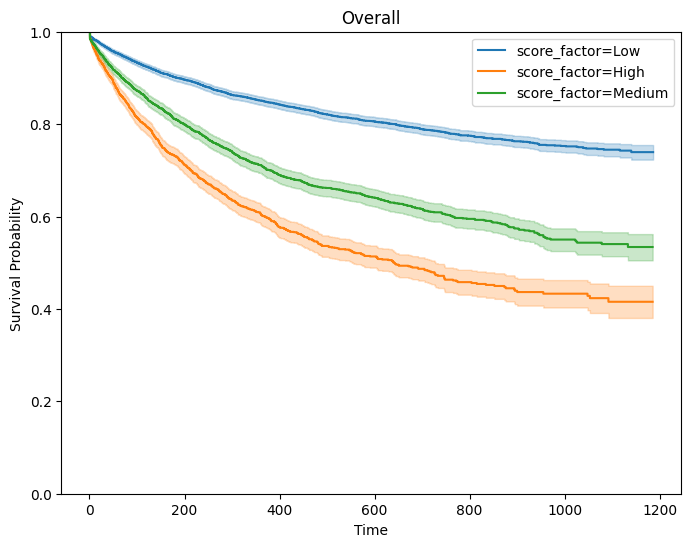

In [41]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for label in data["score_factor"].unique():
    subset = data[data["score_factor"] == label]
    kmf.fit(
        durations=subset["end"] - subset["start"],
        event_observed=subset["event"],
        label=f"score_factor={label}"
    )
    kmf.plot_survival_function()

plt.title("Overall")
plt.ylim(0,1)
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()

Black defendants do recidivate at higher rates according to race specific Kaplan Meier plots.

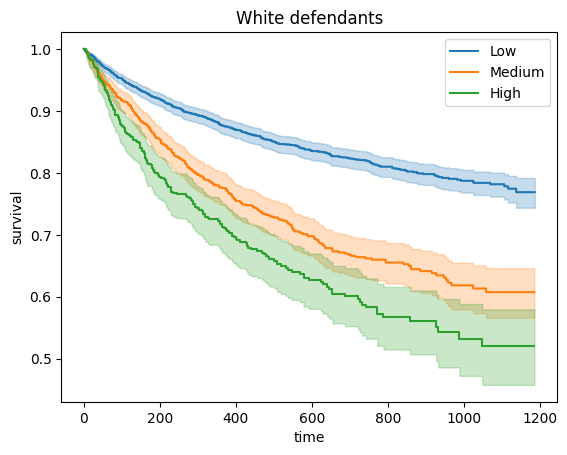

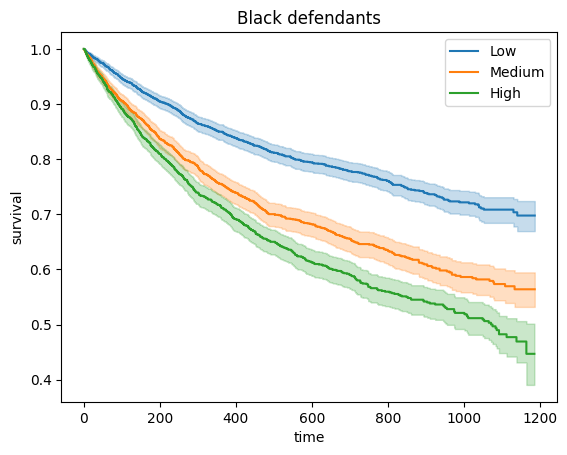

In [42]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

# White
white = data[data["race"] == "Caucasian"]

plt.figure()

for group in ["Low", "Medium", "High"]:
    subset = white[white["score_text"] == group]
    kmf.fit(subset["end"], event_observed=subset["event"], label=group)
    kmf.plot()

plt.title("White defendants")
plt.xlabel("time")
plt.ylabel("survival")
plt.show()


# Black
black = data[data["race"] == "African-American"]

plt.figure()

for group in ["Low", "Medium", "High"]:
    subset = black[black["score_text"] == group]
    kmf.fit(subset["end"], event_observed=subset["event"], label=group)
    kmf.plot()

plt.title("Black defendants")
plt.xlabel("time")
plt.ylabel("survival")
plt.show()

In [43]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

# Overall
print("=== Overall ===")
for group in ["Low", "Medium", "High"]:
    subset = data[data["score_text"] == group]
    kmf.fit(subset["end"], event_observed=subset["event"])
    surv = kmf.survival_function_at_times(730)
    print(f"{group}: {float(surv.iloc[0]):.3f}")

# White
print("\n=== White defendants ===")
white = data[data["race"] == "Caucasian"]

for group in ["Low", "Medium", "High"]:
    subset = white[white["score_text"] == group]
    kmf.fit(subset["end"], event_observed=subset["event"])
    surv = kmf.survival_function_at_times(730)
    print(f"{group}: {float(surv.iloc[0]):.3f}")

# Black
print("\n=== Black defendants ===")
black = data[data["race"] == "African-American"]

for group in ["Low", "Medium", "High"]:
    subset = black[black["score_text"] == group]
    kmf.fit(subset["end"], event_observed=subset["event"])
    surv = kmf.survival_function_at_times(730)
    print(f"{group}: {float(surv.iloc[0]):.3f}")

=== Overall ===
Low: 0.802
Medium: 0.656
High: 0.581

=== White defendants ===
Low: 0.821
Medium: 0.664
High: 0.592

=== Black defendants ===
Low: 0.775
Medium: 0.646
High: 0.575


Race specific models have similar concordance values.

In [44]:
from lifelines import CoxTimeVaryingFitter
import pandas as pd

# White-only Cox model
white_data = data[data["race"] == "Caucasian"].copy()
white_data["score_factor"] = pd.Categorical(
    white_data["score_text"],
    categories=["Low", "High", "Medium"]
)

white_cox = white_data[["id", "start", "end", "event", "score_factor"]].copy()
white_cox = pd.get_dummies(white_cox, columns=["score_factor"], drop_first=True)

ctv_white = CoxTimeVaryingFitter()
ctv_white.fit(
    white_cox,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event"
)

print("=== White defendants ===")
ctv_white.print_summary()


# Black-only Cox model
black_data = data[data["race"] == "African-American"].copy()
black_data["score_factor"] = pd.Categorical(
    black_data["score_text"],
    categories=["Low", "High", "Medium"]
)

black_cox = black_data[["id", "start", "end", "event", "score_factor"]].copy()
black_cox = pd.get_dummies(black_cox, columns=["score_factor"], drop_first=True)

ctv_black = CoxTimeVaryingFitter()
ctv_black.fit(
    black_cox,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event"
)

print("\n=== Black defendants ===")
ctv_black.print_summary()

=== White defendants ===


<lifelines.CoxTimeVaryingFitter: fitted with 4564 periods, 3569 subjects, 1023 events>
         event col = 'event'
number of subjects = 3569
 number of periods = 4564
  number of events = 1023
partial log-likelihood = -7919.63
  time fit was run = 2026-03-30 07:49:19 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_High    1.28      3.58      0.08            1.11            1.44                3.04                4.22
score_factor_Medium  0.84      2.32      0.07            0.70            0.98                2.01                2.66

                     cmp to     z      p  -log2(p)
covariate                                         
score_factor_High      0.00 15.26 <0.005    172.18
score_factor_Medium    0.00 11.75 <0.005    103.54
---
Partial AIC = 15843.27
log-likelihood ratio test = 262.78 on 2 df
-log2(p) of ll-ratio test = 189.56


=== Black defendants ===


<lifelines.CoxTimeVaryingFitter: fitted with 6862 periods, 5147 subjects, 2035 events>
         event col = 'event'
number of subjects = 5147
 number of periods = 6862
  number of events = 2035
partial log-likelihood = -16302.68
  time fit was run = 2026-03-30 07:49:20 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_High    1.10      2.99      0.05            0.99            1.20                2.69                3.33
score_factor_Medium  0.67      1.95      0.06            0.56            0.78                1.75                2.18

                     cmp to     z      p  -log2(p)
covariate                                         
score_factor_High      0.00 20.00 <0.005    293.26
score_factor_Medium    0.00 11.89 <0.005    105.92
---
Partial AIC = 32609.37
log-likelihood ratio test = 416.91 on 2 df
-log2(p) of ll-ratio test = 300.74

Compas's violent recidivism score has a slightly higher overall concordance score of 65.1%.

In [45]:
# Load violent dataset
violent_url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-violent-parsed.csv"
violent_data = pd.read_csv(violent_url)

# Filter (same logic as before)
violent_data = violent_data[
    (violent_data["score_text"].notna()) &
    (violent_data["end"] > violent_data["start"])
].copy()

# Create categorical variables
violent_data["score_factor"] = pd.Categorical(
    violent_data["score_text"],
    categories=["Low", "High", "Medium"]
)

# Drop duplicate ids (same as grp in R)
violent_grp = violent_data.drop_duplicates(subset="id").copy()
print(len(violent_grp))

# Prepare Cox data
violent_cox = violent_data[["id", "start", "end", "event", "score_factor"]].copy()
violent_cox = pd.get_dummies(violent_cox, columns=["score_factor"], drop_first=True)

# Fit model
ctv_violent = CoxTimeVaryingFitter()
ctv_violent.fit(
    violent_cox,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event"
)

ctv_violent.print_summary()

10985


<lifelines.CoxTimeVaryingFitter: fitted with 18178 periods, 10985 subjects, 818 events>
         event col = 'event'
number of subjects = 10985
 number of periods = 18178
  number of events = 818
partial log-likelihood = -7251.00
  time fit was run = 2026-03-30 07:49:25 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_High    1.38      3.99      0.08            1.22            1.55                3.38                4.70
score_factor_Medium  0.80      2.23      0.09            0.63            0.97                1.88                2.65

                     cmp to     z      p  -log2(p)
covariate                                         
score_factor_High      0.00 16.45 <0.005    199.49
score_factor_Medium    0.00  9.24 <0.005     65.09
---
Partial AIC = 14505.99
log-likelihood ratio test = 270.64 on 2 df
-log2(p) of ll-ratio test = 195.23

In this case, there isn't a significant coefficient on African American's with High Scores.

In [46]:
print(interaction_data.columns.tolist())

['id', 'start', 'end', 'event', 'race_factor_African-American', 'race_factor_Asian', 'race_factor_Hispanic', 'race_factor_Native American', 'race_factor_Other', 'score_factor_High', 'score_factor_Medium', 'AA_High', 'AA_Medium', 'Asian_High', 'Asian_Medium', 'Hispanic_High', 'Hispanic_Medium', 'NativeAmerican_High', 'NativeAmerican_Medium', 'Other_High', 'Other_Medium']


In [47]:
from lifelines import CoxTimeVaryingFitter
import pandas as pd

interaction_data = data[["id", "start", "end", "event", "race", "score_text"]].copy()

interaction_data = pd.get_dummies(
    interaction_data,
    columns=["race", "score_text"],
    drop_first=True
)

# Interaction terms using the columns that actually exist
interaction_data["Asian_Low"] = (
    interaction_data["race_Asian"] *
    interaction_data["score_text_Low"]
)

interaction_data["Asian_Medium"] = (
    interaction_data["race_Asian"] *
    interaction_data["score_text_Medium"]
)

interaction_data["Caucasian_Low"] = (
    interaction_data["race_Caucasian"] *
    interaction_data["score_text_Low"]
)

interaction_data["Caucasian_Medium"] = (
    interaction_data["race_Caucasian"] *
    interaction_data["score_text_Medium"]
)

interaction_data["Hispanic_Low"] = (
    interaction_data["race_Hispanic"] *
    interaction_data["score_text_Low"]
)

interaction_data["Hispanic_Medium"] = (
    interaction_data["race_Hispanic"] *
    interaction_data["score_text_Medium"]
)

interaction_data["NativeAmerican_Low"] = (
    interaction_data["race_Native American"] *
    interaction_data["score_text_Low"]
)

interaction_data["NativeAmerican_Medium"] = (
    interaction_data["race_Native American"] *
    interaction_data["score_text_Medium"]
)

interaction_data["Other_Low"] = (
    interaction_data["race_Other"] *
    interaction_data["score_text_Low"]
)

interaction_data["Other_Medium"] = (
    interaction_data["race_Other"] *
    interaction_data["score_text_Medium"]
)

ctv_interaction = CoxTimeVaryingFitter()
ctv_interaction.fit(
    interaction_data,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event"
)

ctv_interaction.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 13344 periods, 10314 subjects, 3469 events>
         event col = 'event'
number of subjects = 10314
 number of periods = 13344
  number of events = 3469
partial log-likelihood = -30280.41
  time fit was run = 2026-03-30 07:49:29 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
race_Asian             0.45      1.57      0.58           -0.68            1.58                0.50                4.87
race_Caucasian        -0.09      0.91      0.08           -0.24            0.07                0.78                1.07
race_Hispanic         -0.27      0.76      0.16           -0.59            0.05                0.55                1.05
race_Native American   0.61      1.84      0.41           -0.19            1.42                0.83                4.12
race_Other             0.34      1.40      0.23           -0.10            0.78                0.90                2.19
score_text_Low        -1.09      0.33      0.05           -1.20           -0.99                0.30                0.37
score_text_Medium     -0.42      0.65      0.05           -0.53           -0.32                0.59                0.73
Asian_Low             -1.51      0.22      0.77           -3.01           -0.00                0.05                1.00
Asian_Medium          -0.35      0.71      0.77           -1.85            1.15                0.16                3.17
Caucasian_Low         -0.19      0.83      0.10           -0.39            0.01                0.68                1.01
Caucasian_Medium      -0.02      0.98      0.10           -0.22            0.19                0.80                1.21
Hispanic_Low          -0.07      0.93      0.19           -0.44            0.30                0.64                1.35
Hispanic_Medium        0.17      1.18      0.21           -0.24            0.57                0.79                1.77
NativeAmerican_Low    -2.15      0.12      1.08           -4.27           -0.03                0.01                0.97
NativeAmerican_Medium -0.58      0.56      0.65           -1.85            0.69                0.16                1.99
Other_Low             -0.60      0.55      0.25           -1.10           -0.11                0.33                0.89
Other_Medium          -0.77      0.47      0.30           -1.36           -0.17                0.26                0.84

                       cmp to      z      p  -log2(p)
covariate                                            
race_Asian               0.00   0.78   0.44      1.19
race_Caucasian           0.00  -1.12   0.26      1.94
race_Hispanic            0.00  -1.68   0.09      3.41
race_Native American     0.00   1.49   0.14      2.88
race_Other               0.00   1.50   0.13      2.90
score_text_Low           0.00 -19.99 <0.005    292.79
score_text_Medium        0.00  -8.03 <0.005     49.81
Asian_Low                0.00  -1.97   0.05      4.34
Asian_Medium             0.00  -0.45   0.65      0.62
Caucasian_Low            0.00  -1.90   0.06      4.12
Caucasian_Medium         0.00  -0.16   0.87      0.20
Hispanic_Low             0.00  -0.38   0.71      0.50
Hispanic_Medium          0.00   0.81   0.42      1.27
NativeAmerican_Low       0.00  -1.98   0.05      4.40
NativeAmerican_Medium    0.00  -0.90   0.37      1.44
Other_Low                0.00  -2.40   0.02      5.95
Other_Medium             0.00  -2.53   0.01      6.47
---
Partial AIC = 60594.82
log-likelihood ratio test = 993.71 on 17 df
-log2(p) of ll-ratio test = 663.39

In [48]:
from lifelines import CoxTimeVaryingFitter
import pandas as pd

# African-American only
violent_black = violent_data[violent_data["race"] == "African-American"].copy()
violent_black["score_factor"] = pd.Categorical(
    violent_black["score_text"],
    categories=["Low", "High", "Medium"]
)

violent_black_cox = violent_black[["id", "start", "end", "event", "score_factor"]].copy()
violent_black_cox = pd.get_dummies(
    violent_black_cox,
    columns=["score_factor"],
    drop_first=True
)

ctv_violent_black = CoxTimeVaryingFitter()
ctv_violent_black.fit(
    violent_black_cox,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event"
)

print("=== African-American defendants (violent model) ===")
ctv_violent_black.print_summary()


# Caucasian only
violent_white = violent_data[violent_data["race"] == "Caucasian"].copy()
violent_white["score_factor"] = pd.Categorical(
    violent_white["score_text"],
    categories=["Low", "High", "Medium"]
)

violent_white_cox = violent_white[["id", "start", "end", "event", "score_factor"]].copy()
violent_white_cox = pd.get_dummies(
    violent_white_cox,
    columns=["score_factor"],
    drop_first=True
)

ctv_violent_white = CoxTimeVaryingFitter()
ctv_violent_white.fit(
    violent_white_cox,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event"
)

print("\n=== Caucasian defendants (violent model) ===")
ctv_violent_white.print_summary()

=== African-American defendants (violent model) ===


<lifelines.CoxTimeVaryingFitter: fitted with 9712 periods, 5440 subjects, 495 events>
         event col = 'event'
number of subjects = 5440
 number of periods = 9712
  number of events = 495
partial log-likelihood = -4041.61
  time fit was run = 2026-03-30 07:49:54 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_High    1.24      3.46      0.11            1.02            1.46                2.77                4.33
score_factor_Medium  0.76      2.14      0.12            0.52            0.99                1.69                2.70

                     cmp to     z      p  -log2(p)
covariate                                         
score_factor_High      0.00 10.89 <0.005     89.35
score_factor_Medium    0.00  6.31 <0.005     31.78
---
Partial AIC = 8087.22
log-likelihood ratio test = 127.46 on 2 df
-log2(p) of ll-ratio test = 91.94


=== Caucasian defendants (violent model) ===


<lifelines.CoxTimeVaryingFitter: fitted with 6041 periods, 3821 subjects, 221 events>
         event col = 'event'
number of subjects = 3821
 number of periods = 6041
  number of events = 221
partial log-likelihood = -1749.36
  time fit was run = 2026-03-30 07:49:55 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_High    1.25      3.49      0.17            0.91            1.59                2.49                4.89
score_factor_Medium  0.63      1.88      0.16            0.32            0.94                1.38                2.56

                     cmp to    z      p  -log2(p)
covariate                                        
score_factor_High      0.00 7.27 <0.005     41.31
score_factor_Medium    0.00 3.99 <0.005     13.86
---
Partial AIC = 3502.73
log-likelihood ratio test = 49.63 on 2 df
-log2(p) of ll-ratio test = 35.80

The race-specific Cox models for the violent recidivism dataset show very similar patterns across groups.

For both African-American and Caucasian defendants, individuals classified as High risk have substantially higher hazard ratios compared to Low risk individuals. Medium risk individuals also show elevated hazard, though smaller than High risk.

This suggests that the COMPAS violent score consistently separates risk levels within each racial group.

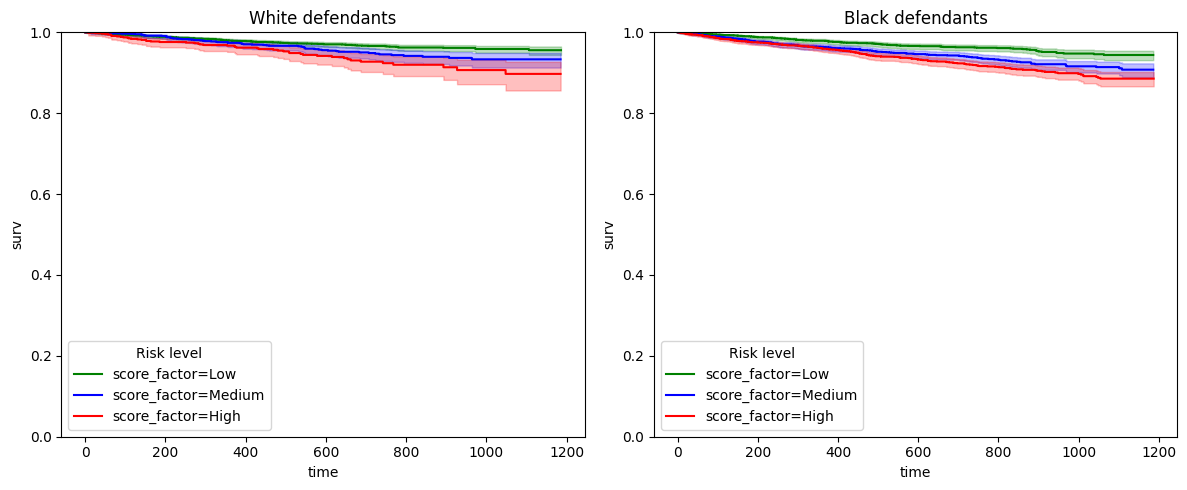

In [49]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

# Match the R plot colors
colors = {
    "Low": "green",
    "Medium": "blue",
    "High": "red"
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# White defendants
white = violent_data[violent_data["race"] == "Caucasian"]

for group in ["Low", "Medium", "High"]:
    subset = white[white["score_text"] == group]
    kmf.fit(
        durations=subset["end"],
        event_observed=subset["event"],
        label=f"score_factor={group}"
    )
    kmf.plot_survival_function(ax=axes[0], color=colors[group])

axes[0].set_title("White defendants")
axes[0].set_xlabel("time")
axes[0].set_ylabel("surv")
axes[0].set_ylim(0, 1)
axes[0].legend(title="Risk level")

# Black defendants
black = violent_data[violent_data["race"] == "African-American"]

for group in ["Low", "Medium", "High"]:
    subset = black[black["score_text"] == group]
    kmf.fit(
        durations=subset["end"],
        event_observed=subset["event"],
        label=f"score_factor={group}"
    )
    kmf.plot_survival_function(ax=axes[1], color=colors[group])

axes[1].set_title("Black defendants")
axes[1].set_xlabel("time")
axes[1].set_ylabel("surv")
axes[1].set_ylim(0, 1)
axes[1].legend(title="Risk level")

plt.tight_layout()
plt.show()

The survival curves show clear separation between risk groups. Individuals classified as High risk have the lowest survival probabilities over time, while Low-risk individuals have the highest. This pattern is consistent across both African-American and Caucasian defendants, indicating that the COMPAS score meaningfully differentiates risk levels in both groups.


## Directions of the Racial Bias

The above analysis shows that the Compas algorithm does overpredict African-American defendant's future recidivism, but we haven't yet explored the direction of the bias. We can discover fine differences in overprediction and underprediction by comparing Compas scores across racial lines.

In [50]:
# === Create binary prediction ===
violent_df = df.copy()

# Keep only Low / High
violent_df = violent_df[violent_df["v_score_text"].isin(["Low", "High"])].copy()

violent_df["pred_high"] = (violent_df["v_score_text"] == "High").astype(int)
violent_df["actual_recid"] = violent_df["two_year_recid"].astype(int)

# === Function ===
def show_confusion_table(data, title=""):
    table = pd.crosstab(data["actual_recid"], data["pred_high"])
    table = table.reindex(index=[0,1], columns=[0,1], fill_value=0)

    table.index = ["Survived", "Recidivated"]
    table.columns = ["Low", "High"]

    TN = table.loc["Survived", "Low"]
    FP = table.loc["Survived", "High"]
    FN = table.loc["Recidivated", "Low"]
    TP = table.loc["Recidivated", "High"]

    total = TN + FP + FN + TP

    fpr = FP / (FP + TN) * 100
    fnr = FN / (FN + TP) * 100
    specificity = TN / (TN + FP)
    sensitivity = TP / (TP + FN)

    print(title)
    print(table)
    print(f"Total: {total:.2f}")
    print(f"False positive rate: {fpr:.2f}")
    print(f"False negative rate: {fnr:.2f}")
    print(f"Specificity: {specificity:.2f}")
    print(f"Sensitivity: {sensitivity:.2f}")
    print()

    return {"FPR": fpr, "FNR": fnr}

# === All ===
all_results = show_confusion_table(violent_df, "All defendants")

# === Black ===
black_df = violent_df[violent_df["race"] == "African-American"]
black_results = show_confusion_table(black_df, "Black defendants")

# === White ===
white_df = violent_df[violent_df["race"] == "Caucasian"]
white_results = show_confusion_table(white_df, "White defendants")

# === Ratio ===
print("FPR ratio (Black / White):", black_results["FPR"] / white_results["FPR"])

All defendants
              Low  High
Survived     2607   142
Recidivated   306   137
Total: 3192.00
False positive rate: 5.17
False negative rate: 69.07
Specificity: 0.95
Sensitivity: 0.31

Black defendants
              Low  High
Survived     1046   102
Recidivated   154   101
Total: 1403.00
False positive rate: 8.89
False negative rate: 60.39
Specificity: 0.91
Sensitivity: 0.40

White defendants
              Low  High
Survived     1087    30
Recidivated   110    20
Total: 1247.00
False positive rate: 2.69
False negative rate: 84.62
Specificity: 0.97
Sensitivity: 0.15

FPR ratio (Black / White): 3.308188153310105


Overall, the false positive rate is 32.35%.

In [51]:
TN = 2681
FP = 1282

FPR = FP / (FP + TN)
print(FPR * 100)

32.349230381024476


That number is higher for African Americans at 44.85%.

Survived
Low = TN = 990
High = FP = 805

In [52]:
FPR = (805 / (805 + 990)) * 100
print(FPR)

44.84679665738162


And lower for whites at 23.45%.

In [53]:
FPR = (349 / (349 + 1139)) * 100
print(FPR)

23.45430107526882


Which means under COMPAS black defendants are 91% more likely to get a higher score and not go on to commit more crimes than white defendants after two year.

In [54]:
44.85 / 23.45

1.9125799573560769

COMPAS scores misclassify white reoffenders as low risk at 70.4% more often than black reoffenders.

In [55]:
47.72 / 27.99

1.7048946052161487

## Risk of Violent Recidivism

Compas also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score.

In [56]:
# === Violent Recidivism ===
violent_df = df.copy()

# Low / Highだけ使う
violent_df = violent_df[violent_df["v_score_text"].isin(["Low", "High"])].copy()

# 予測
violent_df["pred_high"] = (violent_df["v_score_text"] == "High").astype(int)

# 実際
violent_df["actual_recid"] = violent_df["two_year_recid"].astype(int)

# === All defendants ===
all_results_v = show_confusion_table(violent_df, "All defendants (violent)")

# === Black defendants ===
black_v = violent_df[violent_df["race"] == "African-American"]
black_results_v = show_confusion_table(black_v, "Black defendants (violent)")

# === White defendants ===
white_v = violent_df[violent_df["race"] == "Caucasian"]
white_results_v = show_confusion_table(white_v, "White defendants (violent)")

# === Ratio ===
print("FPR ratio (Black / White):", black_results_v["FPR"] / white_results_v["FPR"])

All defendants (violent)
              Low  High
Survived     2607   142
Recidivated   306   137
Total: 3192.00
False positive rate: 5.17
False negative rate: 69.07
Specificity: 0.95
Sensitivity: 0.31

Black defendants (violent)
              Low  High
Survived     1046   102
Recidivated   154   101
Total: 1403.00
False positive rate: 8.89
False negative rate: 60.39
Specificity: 0.91
Sensitivity: 0.40

White defendants (violent)
              Low  High
Survived     1087    30
Recidivated   110    20
Total: 1247.00
False positive rate: 2.69
False negative rate: 84.62
Specificity: 0.97
Sensitivity: 0.15

FPR ratio (Black / White): 3.308188153310105


In [57]:
print(df.columns.tolist())
print(df[["v_score_text", "race", "two_year_recid"]].head())
print(violent_df["v_score_text"].value_counts())

['age', 'c_charge_degree', 'race', 'age_cat', 'v_score_text', 'sex', 'priors_count', 'days_b_screening_arrest', 'v_decile_score', 'is_recid', 'two_year_recid']
  v_score_text              race  two_year_recid
0          Low             Other               0
1          Low  African-American               1
4          Low             Other               0
5          Low             Other               0
6          Low         Caucasian               0
v_score_text
Low     2913
High     279
Name: count, dtype: int64


Even moreso for Black defendants.

Black defendants are twice as likely to be false positives for a Higher violent score than white defendants.

In [58]:
38.14 / 18.46

2.066088840736728

White defendants are 63% more likely to get a lower score and commit another crime than Black defendants.

In [59]:
62.62 / 38.37

1.63200416992442

## Gender differences in Compas scores

In terms of underlying recidivism rates, we can look at gender specific Kaplan Meier estimates. There is a striking difference between women and men.

In [60]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

In [61]:
!pip install lifelines

In [62]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

In [63]:
data["score_factor"] = data["score_text"]

In [64]:
female = data[data["sex"] == "Female"].copy()
male = data[data["sex"] == "Male"].copy()

In [65]:
kmf = KaplanMeierFitter()

print("Female")
for score in ["Low", "Medium", "High"]:
    temp = female[female["score_factor"] == score]
    kmf.fit(
        durations=temp["end"] - temp["start"],
        event_observed=temp["event"],
        label=score
    )
    print(score, "survival at 730 days =", round(kmf.predict(730), 3))

print()

print("Male")
for score in ["Low", "Medium", "High"]:
    temp = male[male["score_factor"] == score]
    kmf.fit(
        durations=temp["end"] - temp["start"],
        event_observed=temp["event"],
        label=score
    )
    print(score, "survival at 730 days =", round(kmf.predict(730), 3))

Female
Low survival at 730 days = 0.842
Medium survival at 730 days = 0.68
High survival at 730 days = 0.582

Male
Low survival at 730 days = 0.77
Medium survival at 730 days = 0.589
High survival at 730 days = 0.454


As these plots show, the Compas score treats a High risk women the same as a Medium risk man.

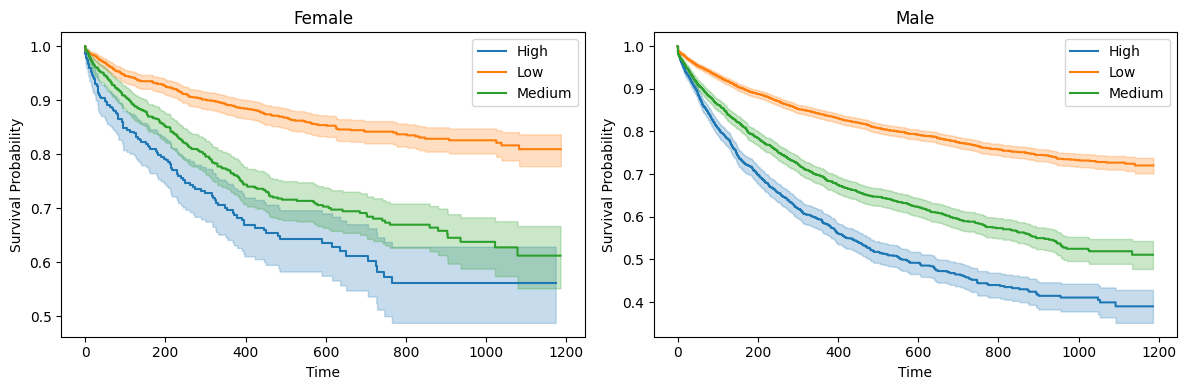

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Female
for score in ["High", "Low", "Medium"]:
    temp = female[female["score_factor"] == score]
    kmf.fit(
        durations=temp["end"] - temp["start"],
        event_observed=temp["event"],
        label=score
    )
    kmf.plot(ax=axes[0], ci_show=True)

axes[0].set_title("Female")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Survival Probability")

# Male
for score in ["High", "Low", "Medium"]:
    temp = male[male["score_factor"] == score]
    kmf.fit(
        durations=temp["end"] - temp["start"],
        event_observed=temp["event"],
        label=score
    )
    kmf.plot(ax=axes[1], ci_show=True)

axes[1].set_title("Male")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Survival Probability")

plt.tight_layout()
plt.show()

In [67]:
print(len(df))
print(df["race"].value_counts(normalize=True)*100)
print((df["two_year_recid"]==1).mean()*100)

4020
race
African-American    47.711443
Caucasian           36.293532
Hispanic             8.830846
Other                6.343284
Asian                0.646766
Native American      0.174129
Name: proportion, dtype: float64
16.218905472636816


## Discussion of Code and Results

In this analysis, I translated the original COMPAS workflow into Python and replicated the main steps, including data preprocessing, exploratory analysis, and model estimation.

First, I applied several filtering conditions to improve data quality, reducing the dataset from 7,214 to 6,172 observations. This ensured that the analysis was conducted on a consistent and reliable subset of the data.

Exploratory analysis showed that African-American defendants make up the largest proportion of the sample (51.44%), followed by Caucasian defendants (34.07%), with an overall two-year recidivism rate of approximately 45.5%. The correlation between COMPAS scores and length of stay was weak (≈0.21), suggesting that higher scores are not strongly associated with time spent in custody.

Using logistic regression, I found that race remains a statistically significant predictor of COMPAS scores even after controlling for relevant variables. African-American defendants are approximately 1.45 times more likely than Caucasian defendants to receive a higher score. Age also has a strong effect, with individuals under 25 being about 2.5 times more likely to receive a higher score compared to those aged 25–45.

A similar pattern appears in the violent recidivism model. African-American defendants are about 1.77 times more likely to receive a higher violent risk score, and individuals under 25 are more than seven times as likely to receive a higher score. These results indicate that demographic factors continue to play a significant role across different model specifications.

In terms of predictive performance, the Cox model shows that higher COMPAS scores are associated with a higher hazard of recidivism, indicating that the model captures meaningful risk patterns. However, classification analysis reveals that the false positive rate (FPR) is substantially higher for African-American defendants than for Caucasian defendants, suggesting unequal error distribution across groups.

From a broader perspective, these findings highlight a key limitation of evaluating models based solely on overall accuracy. The observed disparities in error rates suggest that the model may violate fairness criteria such as equalized odds, where error rates are expected to be similar across groups. This raises concerns about the use of such models in high-stakes decision-making contexts, including bail and sentencing.

Overall, while the COMPAS model demonstrates predictive validity, it also exhibits systematic differences across demographic groups. This suggests that model evaluation should incorporate both predictive performance and fairness considerations to ensure more equitable outcomes in practice.

**Week 2 Assignment**


SHAP

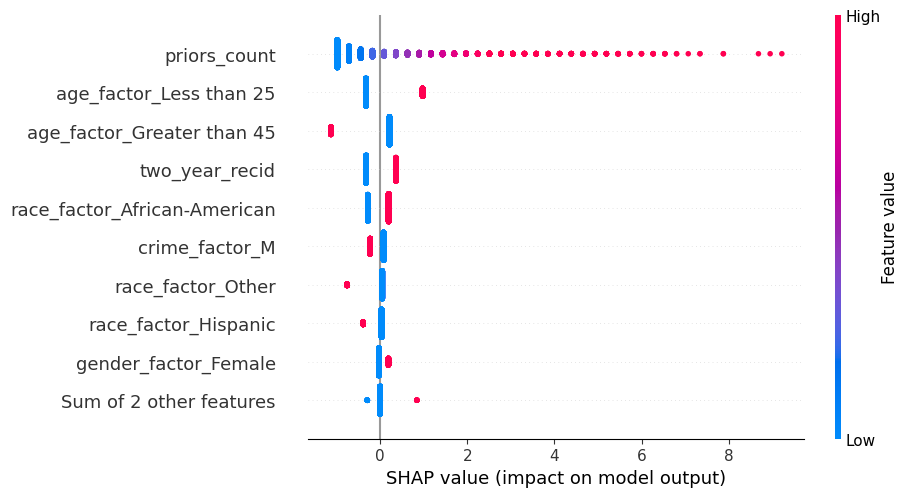

In [68]:

import pandas as pd
import shap
from sklearn.linear_model import LogisticRegression

# Use the same variables from the earlier model
shap_df = df_glm[[
    "gender_factor",
    "age_factor",
    "race_factor",
    "crime_factor",
    "priors_count",
    "two_year_recid",
    "score_factor"
]].copy()

# Convert category columns into dummy variables
X_shap = pd.get_dummies(
    shap_df.drop(columns="score_factor"),
    drop_first=True
)

y_shap = shap_df["score_factor"]

# Make sure all values are numeric
X_shap = X_shap.astype(float)
y_shap = y_shap.astype(int)

# Fit a logistic regression model for SHAP
shap_model = LogisticRegression(max_iter=1000)
shap_model.fit(X_shap, y_shap)

# Build the explainer
explainer = shap.Explainer(shap_model, X_shap)

# Get SHAP values
shap_values = explainer(X_shap)

# Show which variables matter most overall
shap.plots.beeswarm(shap_values)

# Use the same variables from the earlier model
# Convert the category columns into dummy variables
# Make sure everything is numeric before running SHAP
# Fit a logistic regression model for the SHAP part
# Show which variables matter most overall

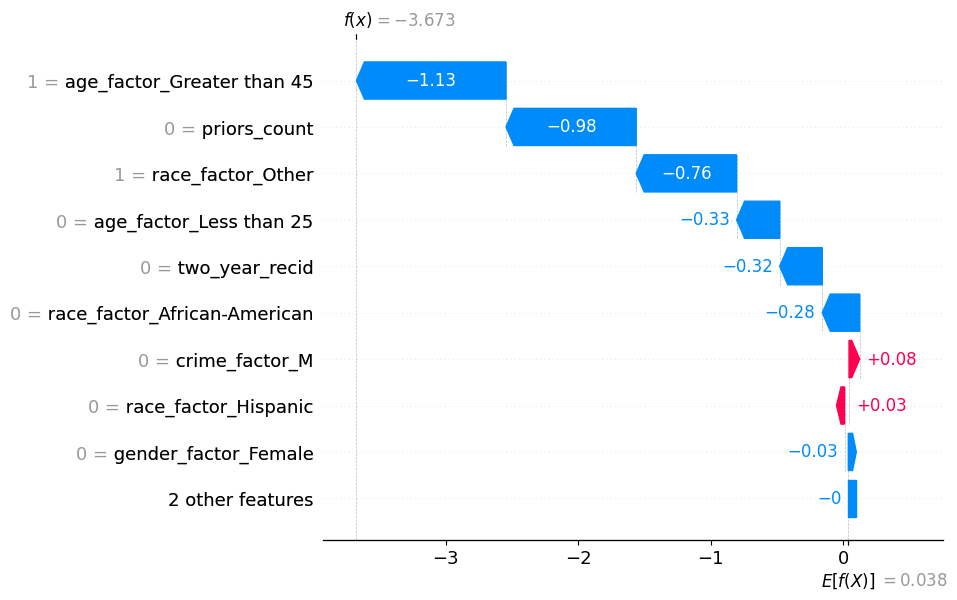

In [69]:
# Look at one person
i = 0
shap.plots.waterfall(shap_values[i])

From the SHAP summary plot, priors_count clearly has the biggest impact on the model.

People with more prior offenses tend to receive higher predicted risk scores, which appears as large positive SHAP values. This is consistent with the earlier regression results, suggesting that the explanation aligns well with the model.

Other variables such as age and two_year_recid also influence the prediction, but their overall impact is smaller compared to priors_count.

The waterfall plot shows how the prediction is built step by step for one individual. In this case, being older than 45 reduces the predicted risk significantly. Having zero prior offenses also pushes the prediction lower, which makes sense given how the model works.

Most of the features in this example contribute to lowering the prediction, so the final risk score is relatively low. Overall, this demonstrates that the prediction is not driven by a single factor, but by a combination of multiple features working together.

##LIME

In [70]:
!pip install lime

In [71]:
from lime.lime_tabular import LimeTabularExplainer

In [72]:
from lime.lime_tabular import LimeTabularExplainer

# Initialize LIME
explainer_lime = LimeTabularExplainer(
    training_data=X_shap.values,
    feature_names=X_shap.columns.tolist(),
    class_names=["Low", "High"],
    mode="classification"
)

# Pick one person
i = 0

# Explain prediction
exp = explainer_lime.explain_instance(
    X_shap.iloc[i].values,
    shap_model.predict_proba
)

# Show result
exp.show_in_notebook()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [73]:
exp.as_list()

[('priors_count <= 0.00', -0.2592928467604919),
 ('age_factor_Less than 25 <= 0.00', -0.239886138287272),
 ('age_factor_Greater than 45 > 0.00', -0.21649861380464744),
 ('race_factor_Native American <= 0.00', -0.1335890649992386),
 ('two_year_recid <= 0.00', -0.117845142657637),
 ('race_factor_Other > 0.00', -0.10012771535094718),
 ('race_factor_African-American <= 0.00', -0.08415916611586947),
 ('race_factor_Hispanic <= 0.00', 0.07248110476400388),
 ('crime_factor_M <= 0.00', 0.062257721524406125),
 ('gender_factor_Female <= 0.00', -0.03737002099317052)]

SHAP and LIME mostly tell a similar story. In both cases, priors_count looks like one of the main variables affecting the prediction, so that part seems pretty consistent. That also matches the regression output from earlier.

Still, the two methods are not exactly the same. SHAP gives a broader picture of how features affect the model, while LIME is more focused on one specific case. Because of that, the size of the contributions can look different even when the same feature appears important in both methods.

From a governance point of view, this means the explanations are useful, but they should not be treated as perfect. When SHAP and LIME agree, it gives more confidence in the result. When they do not fully match, it shows that explanation methods can depend on how they are built and what part of the model they focus on.

Using both methods together helps provide a more complete understanding of the model’s behavior.

In [74]:
!pip install dice-ml

##Counterfactual

In [75]:
import dice_ml
from dice_ml import Dice

# Put the features and target back into one dataframe
dice_df = X_shap.copy()
dice_df["score_factor"] = y_shap

# Features that can be changed
# Race and gender are left out on purpose because they are not actionable
continuous_features = ["priors_count", "two_year_recid"]

# Build DiCE data and model objects
data_dice = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=continuous_features,
    outcome_name="score_factor"
)

model_dice = dice_ml.Model(
    model=shap_model,
    backend="sklearn",
    model_type="classifier"
)

# Create the DiCE explainer
explainer_dice = Dice(data_dice, model_dice, method="random")

# Pick one person
i = 0
query_instance = X_shap.iloc[[i]]

# Generate one counterfactual that flips the prediction
cf = explainer_dice.generate_counterfactuals(
    query_instance,
    total_CFs=1,
    desired_class="opposite"
)

# Show the result
cf.visualize_as_dataframe()

  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is 

Query instance (original outcome : 0)


,priors_count,two_year_recid,gender_factor_Female,age_factor_Greater than 45,age_factor_Less than 25,race_factor_African-American,race_factor_Asian,race_factor_Hispanic,race_factor_Native American,race_factor_Other,crime_factor_M,score_factor
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0



Diverse Counterfactual set (new outcome: 1)


,priors_count,two_year_recid,gender_factor_Female,age_factor_Greater than 45,age_factor_Less than 25,race_factor_African-American,race_factor_Asian,race_factor_Hispanic,race_factor_Native American,race_factor_Other,crime_factor_M,score_factor
0,31.4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1


In [76]:
# Example: run counterfactuals for four individuals
selected_ids = [0, 1, 2, 3]

for i in selected_ids:
    print(f"\nCounterfactual for individual {i}")
    query_instance = X_shap.iloc[[i]]

    cf = explainer_dice.generate_counterfactuals(
        query_instance,
        total_CFs=1,
        desired_class="opposite"
    )

    cf.visualize_as_dataframe()


Counterfactual for individual 0


  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is 

Query instance (original outcome : 0)


,priors_count,two_year_recid,gender_factor_Female,age_factor_Greater than 45,age_factor_Less than 25,race_factor_African-American,race_factor_Asian,race_factor_Hispanic,race_factor_Native American,race_factor_Other,crime_factor_M,score_factor
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0



Diverse Counterfactual set (new outcome: 1)


...

  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is 

Query instance (original outcome : 0)


,priors_count,two_year_recid,gender_factor_Female,age_factor_Greater than 45,age_factor_Less than 25,race_factor_African-American,race_factor_Asian,race_factor_Hispanic,race_factor_Native American,race_factor_Other,crime_factor_M,score_factor
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0



Diverse Counterfactual set (new outcome: 1)


,priors_count,two_year_recid,gender_factor_Female,age_factor_Greater than 45,age_factor_Less than 25,race_factor_African-American,race_factor_Asian,race_factor_Hispanic,race_factor_Native American,race_factor_Other,crime_factor_M,score_factor
0,12.7,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1


The counterfactual result shows the smallest change needed to flip the prediction for this individual.In this case, the model changes its prediction when priors_count is increased significantly. This suggests that prior offenses have a strong influence on the model’s decision.

Other features remain mostly the same, which means the model relies heavily on priors_count to determine the outcome. This result is consistent with both the SHAP and LIME explanations, where priors_count was also one of the most important variables. Also, race and gender were not changed in the counterfactual, since they are not actionable features in practice.

##GOVERNANCE MEMO


To: Court Auditor  
Subject: Model Explanation and Governance Assessment  

This memo summarizes the findings from analyzing the COMPAS replacement model using SHAP, LIME, and counterfactual explanations.

Overall, the results show that the model relies heavily on priors_count when making predictions. Across both SHAP and LIME, prior offenses consistently appear as one of the most important factors influencing the risk score. This suggests that individuals with more prior offenses are more likely to be classified as high risk.

While both SHAP and LIME provide useful explanations, they do not produce identical results. SHAP offers a more consistent, global view of feature importance across the dataset, whereas LIME focuses on explaining individual predictions. Because of this, the feature contributions from LIME can vary depending on the specific case being analyzed. This indicates that explanations are dependent on the method used and should not be treated as exact or absolute.

The counterfactual analysis further supports these findings. In the examples examined, changing priors_count was often sufficient to flip the model’s prediction. Importantly, demographic features such as race and gender were not modified in the counterfactuals, since they are not actionable in practice. This makes the results more meaningful from a decision-making perspective.

However, the presence of demographic variables in the model still raises potential fairness concerns. Even if their impact appears smaller, they may still influence outcomes indirectly.

Based on these findings, it is recommended to use multiple explanation methods when evaluating model behavior and to monitor the model for potential bias over time. In addition, it is important to consider how these explanations are communicated to stakeholders. Clear explanations can improve transparency and trust, especially in high-stakes decisions. Future work could also include additional fairness metrics to better evaluate whether different groups are affected differently by the model.

Thank you.